In [38]:

import pandas as pd
from sklearn.model_selection import train_test_split

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns

## Препроцесинг

Відкриваємо датасет

In [40]:
cards = pd.read_csv('../cards/cards.csv')

In [41]:
cards.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


In [42]:
# Додаємо нову колонку з мітками мастей карт
cards['suit'] = cards['labels'].apply(lambda x: x.split(' ')[-1])
cards['suit'].value_counts()

suit
spades      2161
hearts      1975
diamonds    1957
clubs       1937
joker        125
Name: count, dtype: int64

Візуалізуємо кількість кожного типу карт

<Axes: xlabel='card type', ylabel='count'>

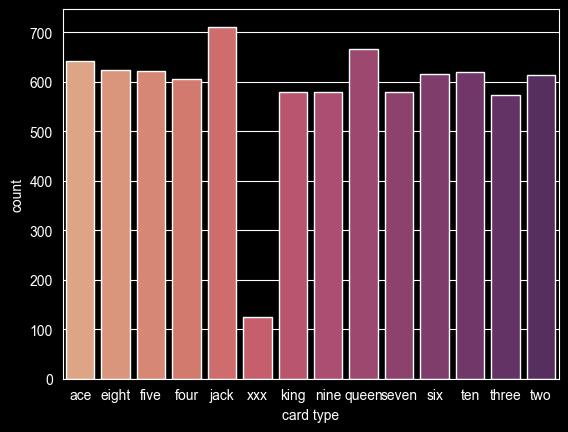

In [43]:
# Seaborn visualization of card types
import seaborn as sns
sns.color_palette("flare")

sns.countplot(x='card type', data=cards, palette='flare', hue='card type')

In [44]:
cards['labels_encoded'] = cards['labels'].astype('category').cat.codes

<Axes: xlabel='labels', ylabel='count'>

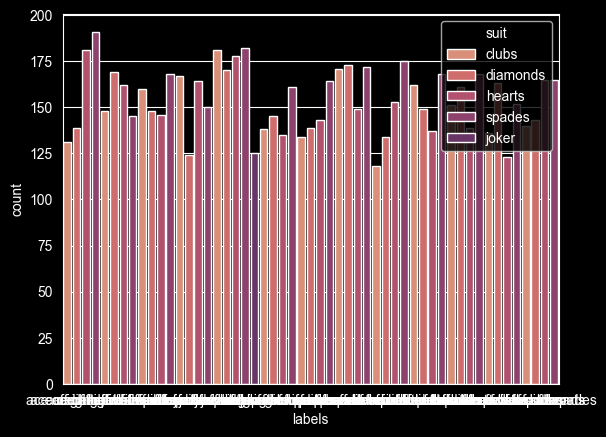

In [45]:
import seaborn as sns
sns.color_palette("flare")
# Visualize the distribution of encoded labels
# No x-axis labels, just the count of each encoded label
sns.countplot(x='labels', data=cards, palette='flare', hue='suit')

В цілому кожного типу карт приблизно однакова кількість. Це нас не влаштовує. Штучно створюємо дисбаланс класів ділячи їх на карти з обличчями та без. Тут "xxx" - це джокери. Джокери в нас з обличчями. Ace - туз - це карта з цифрою. Цифри на ній немає, але обличчя теж і non-face клас звучить не так красиво як number.

In [46]:
cards['type'] = cards['card type'].apply(lambda x: 'face' if any(face in x for face in ['jack', 'queen', 'king', 'xxx']) else 'number')
cards['type suit'] = cards['type'] + ' ' + cards['suit']

Виводимо по 1 карті з кожного класу та показуємо по 1 представнику кожного з 14 типів з підписом класу карти

In [47]:

df_unique = cards.drop_duplicates(subset=['card type'])
df_unique

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs
602,4,train/eight of clubs/001.jpg,eight of clubs,eight,train,clubs,4,number,number clubs
1186,8,train/five of clubs/001.jpg,five of clubs,five,train,clubs,8,number,number clubs
1768,12,train/four of clubs/001.jpg,four of clubs,four,train,clubs,12,number,number clubs
2333,16,train/jack of clubs/001.jpg,jack of clubs,jack,train,clubs,16,face,face clubs
3004,20,train/joker/001.jpg,joker,xxx,train,joker,20,face,face joker
3119,21,train/king of clubs/001.jpg,king of clubs,king,train,clubs,21,face,face clubs
3658,25,train/nine of clubs/001.jpg,nine of clubs,nine,train,clubs,25,number,number clubs
4198,29,train/queen of clubs/001.jpg,queen of clubs,queen,train,clubs,29,face,face clubs
4823,33,train/seven of clubs/001.jpg,seven of clubs,seven,train,clubs,33,number,number clubs


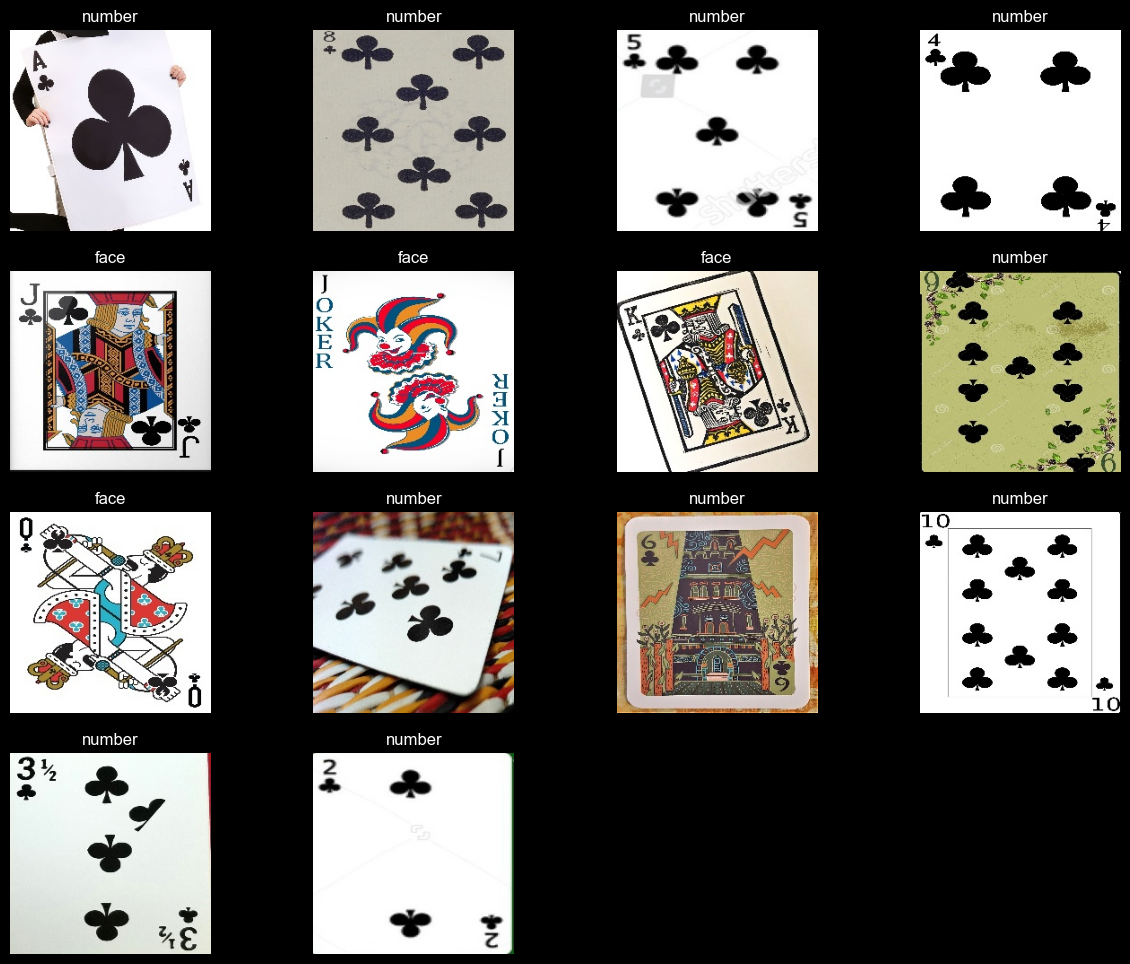

In [48]:
# plot every card with 4 in a row
import matplotlib.pyplot as plt
num_cols = 4
num_rows = 4
plt.figure(figsize=(15, num_rows * 3))
for i, card_path in enumerate(df_unique['filepaths']):
    image_path = f'../cards/{card_path}'
    img = plt.imread(image_path)
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(img)
    plt.title(df_unique.iloc[i]['type'])
    plt.axis('off')

<Axes: xlabel='type', ylabel='count'>

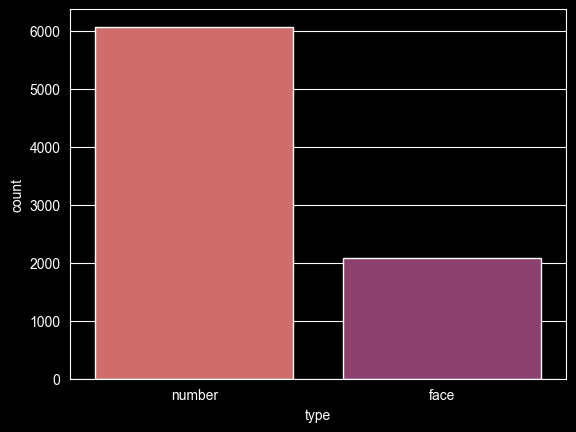

In [49]:
sns.countplot(x='type', data=cards, palette='flare', hue='type')

<Axes: xlabel='type suit', ylabel='count'>

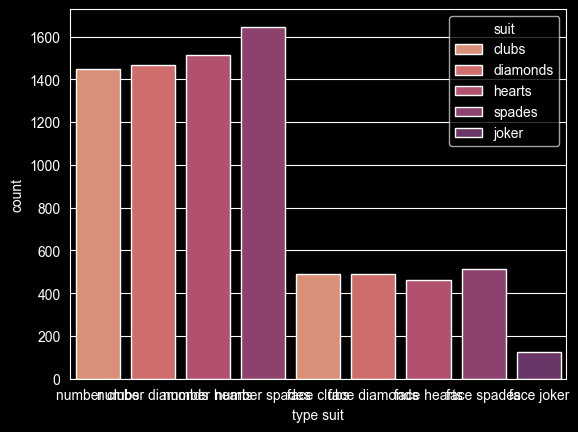

In [50]:
sns.countplot(x='type suit', data=cards, palette='flare', hue='suit')

Тепер датасет більше схожий на незбалансований. Повернемось до карт з обличчями як окремим класам та беремо половину з них.


In [51]:
cards['final_label'] = cards.apply(lambda row: row['type'] if row['type'] == 'number' else row['card type'], axis=1)

In [52]:
# for face cards keep only half of each type. Random half
for face in ['jack', 'queen', 'king', 'xxx']:
    drop_indices = cards[cards['final_label'] == face].sample(frac=0.5, random_state=42).index
    cards.drop(drop_indices, inplace=True)

<Axes: xlabel='final_label', ylabel='count'>

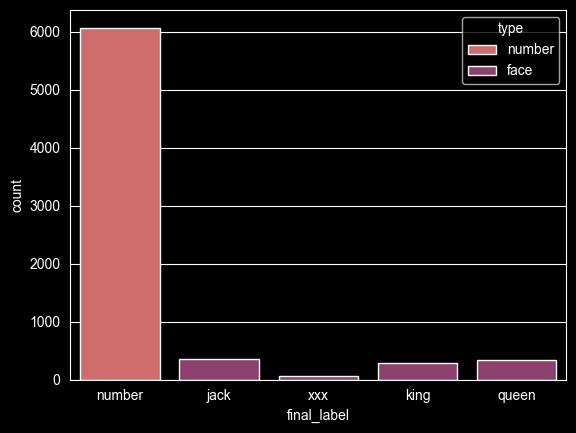

In [53]:
sns.countplot(x='final_label', data=cards, palette='flare', hue='type')

Зберігаємо отриманий датасет у новий CSV файл

In [54]:
cards.to_csv('../cards/processed_cards.csv', index=False)

Датасет готовий. В tensorflow_feature_extraction.ipynb отимуємо features - результати передостаннього шару у вигляді вектора з 256 значень.

In [55]:
cards = pd.read_csv('../cards/featured_cards.csv')

In [56]:
cards.head()

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label,features,extracted_label,card type encoded
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0...,0.0,0
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number,[0. 0. 0. 0. 0...,0.0,0


Конвертуємо датасет в набір значень з колонки ознак та цільового маркеру нашого класу

In [57]:
cards['features'] = cards['features'].apply(lambda x: np.fromstring(x[1:-1], sep=' ') if pd.notnull(x) else None)
# make a df of 256 columns from features



In [84]:
print('лейбли класів:')
cards['encoded'] = cards['final_label'].astype('category').cat.codes
labels = {row['final_label'] : row['encoded'] for i, row in cards.iterrows()}
print(labels)

лейбли класів:
{'number': 2, 'jack': 0, 'xxx': 4, 'king': 1, 'queen': 3}


In [58]:
feature_df = pd.DataFrame.from_records(cards['features'].tolist())
feature_df['final_label'] = cards['final_label'].astype('category').cat.codes
feature_df

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,final_label
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
1,0.0,0.0,0.0,0.0,0.0,0.020846,0.552028,0.0,0.078372,0.0,...,0.0,0.064447,0.000000,0.033223,0.0,0.00000,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.091403,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.02428,0.0,0.0,0.0,2
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.021049,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7109,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.572863,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7110,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.531565,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7111,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.487464,0.000000,0.0,0.00000,0.0,0.0,0.0,2
7112,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.442741,0.000000,0.0,0.00000,0.0,0.0,0.0,2


<Axes: >

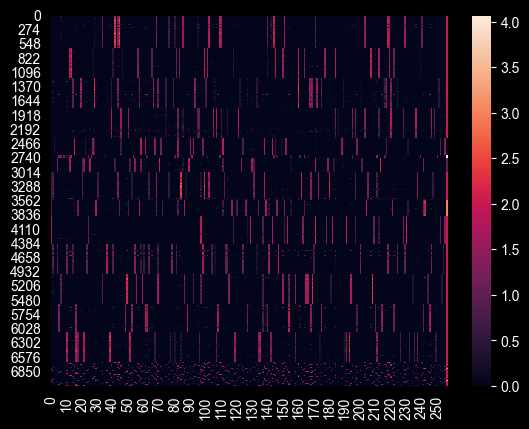

In [59]:
sns.heatmap(feature_df)

## PCA та t-SNE зменшення розмірності

In [60]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt



### PCA (2 компоненти)

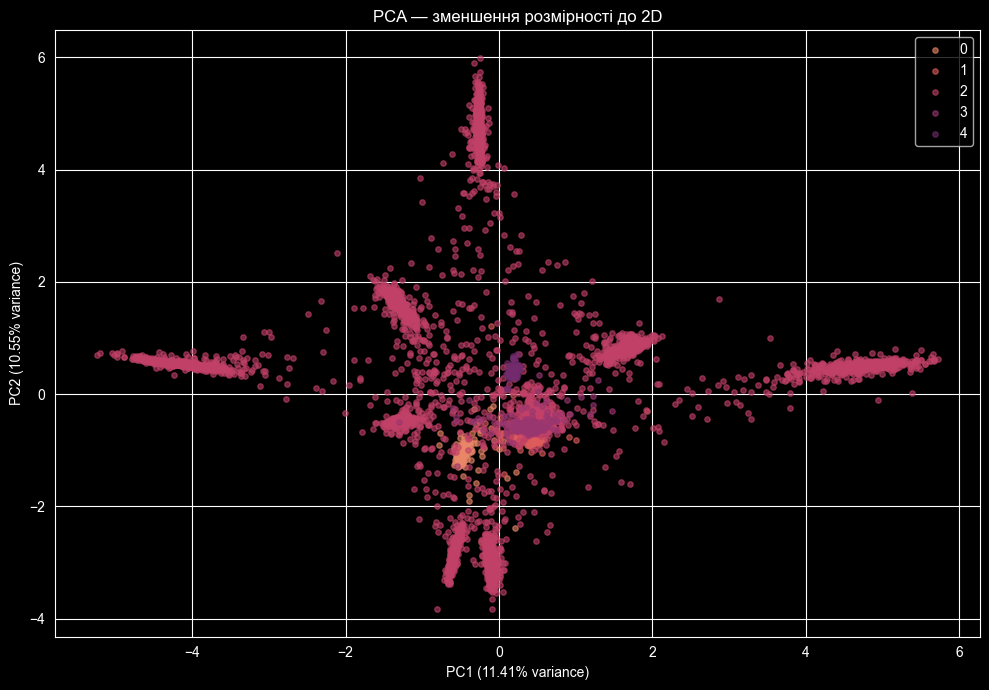

In [61]:
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(feature_df.drop(columns=['final_label']).values)

plt.figure(figsize=(10, 7))
unique_labels = np.unique(feature_df['final_label'].values)
palette = sns.color_palette("flare", len(unique_labels))
for i, label in enumerate(unique_labels):
    y = feature_df['final_label'].values == label
    plt.scatter(x_pca[y, 0], x_pca[y, 1], label=label, color=palette[i], alpha=0.6, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA — зменшення розмірності до 2D')
plt.legend()
plt.tight_layout()
plt.show()

### t-SNE (2 компоненти)

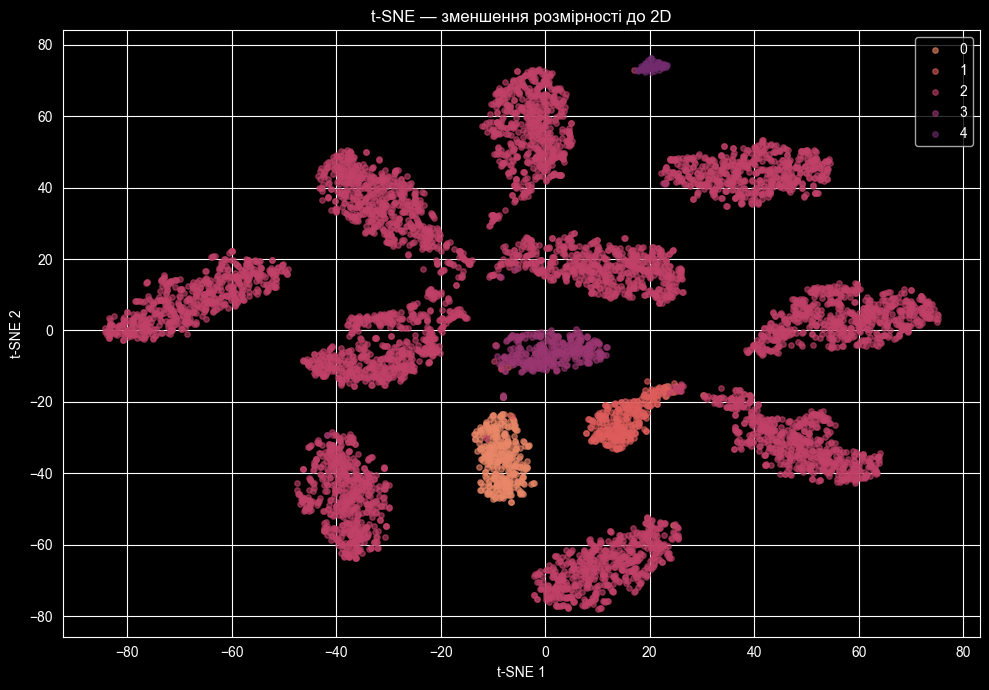

In [62]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
x_tsne = tsne.fit_transform(feature_df.drop(columns=['final_label']).values)

plt.figure(figsize=(10, 7))
for i, label in enumerate(unique_labels):
    y = feature_df['final_label'].values == label
    plt.scatter(x_tsne[y, 0], x_tsne[y, 1], label=label, color=palette[i], alpha=0.6, s=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE — зменшення розмірності до 2D')
plt.legend()
plt.tight_layout()
plt.show()

Можна побачити чо на 2d відображенні, окрім домінації найбільшого класу, відноснo добре видно окремі класи. Це пов'язано з тим що для feature extraction використовувалась модель класифікації цього ж датасету, датасет був з малою кількістю даних та класів та з тим що класи є відносно виразними в цьому датасеті. Тепер ігноруємо внутрішній поділ і наново розділимо його на тренувальний та тестовий набори. Тестова вибірка велика через малу кількість даних для демонстрацї результатів наведених в умові методів. Будуємо вказані в завданні класифікатори

In [63]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(feature_df, test_size=0.5, random_state=42)

## Кмітливий класифікатор

Неправильна модель - геніальна конструкція яка завжди каже що в нас клас number оскільки цей клас найчастіше в даних тренувань

In [105]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, multilabel_confusion_matrix
y_train = train_df['final_label'].values
y_test = test_df['final_label'].values
class TRULY_AWESOME_ACCURATE_MODEL:
	y = 0
	def pred(self, x_test):
		return [self.y for _ in range(len(x_test))]
	def fit(self, x_train, y_train):
	    self.y = np.argmax(np.bincount(y_train))

cls = TRULY_AWESOME_ACCURATE_MODEL()
cls.fit(x_train=train_df.drop(columns=['final_label']).values, y_train = y_train)
y_pred = cls.pred(x_test = test_df.drop(columns=['final_label']).values)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       180
           1       0.00      0.00      0.00       138
           2       0.86      1.00      0.92      3047
           3       0.00      0.00      0.00       163
           4       0.00      0.00      0.00        29

    accuracy                           0.86      3557
   macro avg       0.17      0.20      0.18      3557
weighted avg       0.73      0.86      0.79      3557



C:\LData\LabsKPI13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\LData\LabsKPI13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\LData\LabsKPI13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Отримано чесні 86% точності. Будуємо матрицю невідповідності

Text(33.22222222222222, 0.5, 'Actual')

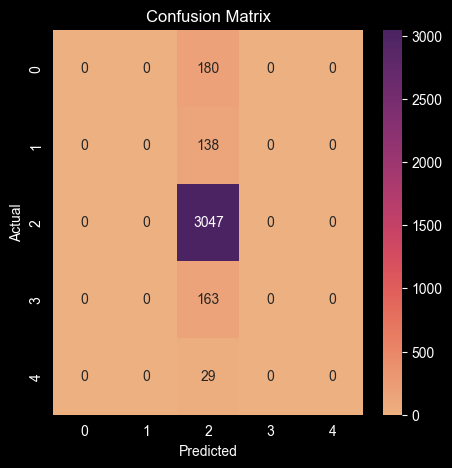

In [122]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=axes,  cmap='flare')
axes.set_title(f"Confusion Matrix")
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

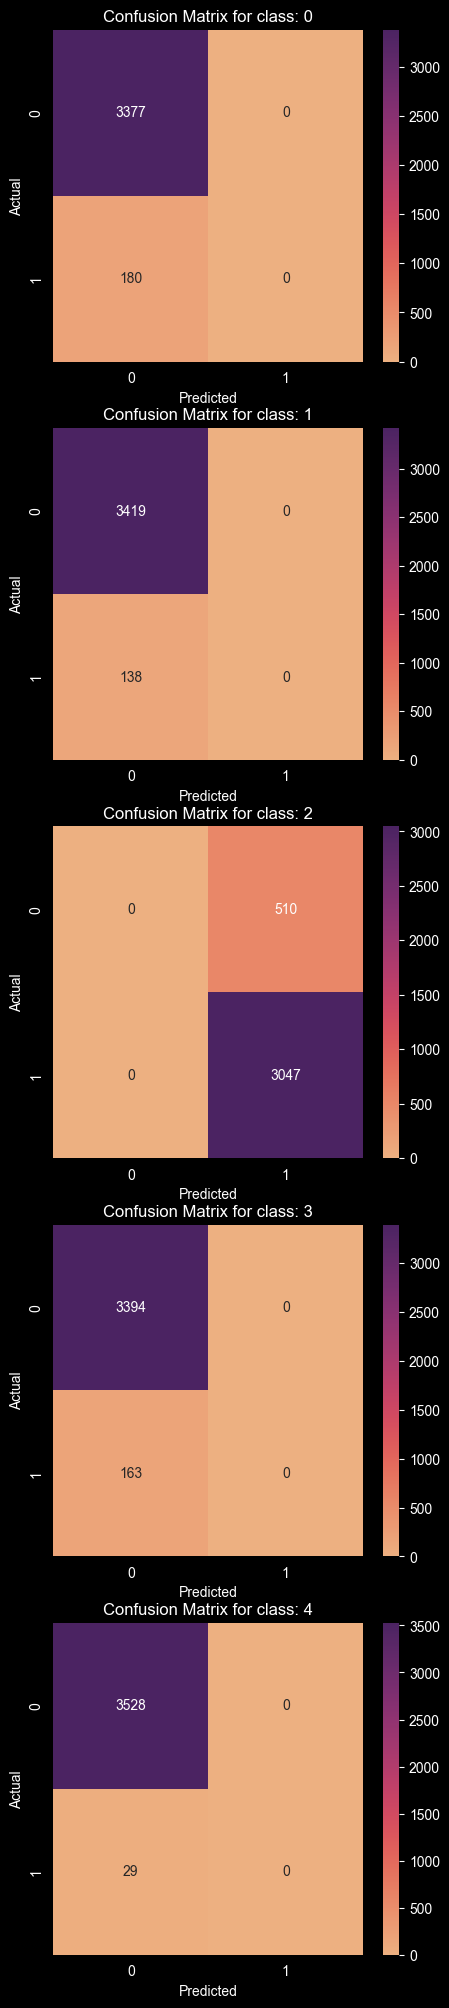

In [123]:
# sns plot confusion matrix
cm = multilabel_confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
for i, (m) in enumerate(cm):
    sns.heatmap(m, annot=True, fmt='d', ax=axes[i],  cmap='flare')
    axes[i].set_title(f"Confusion Matrix for class: {i}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

In [124]:

acc = []
for m in cm:
	#print(m[0][0]+m[1][1])
	acc.append(float((m[0][0]+m[1][1])/sum(sum(m))))
print('Точність по класам:')
acc

Точність по класам:


[0.9493955580545403,
 0.9612032611751476,
 0.8566207478211977,
 0.9541748664605004,
 0.9918470621310093]

Точність по класам така висока оскільки Acc = (True Positive + True Negative)/(True Positive + True Negative + False Positive + False Negative) і в нас дуже висока True Negative для всіх класів крім домінуючого (для нього True Positive)

## Random Forest класифікатор

Будуємо ліс з одного дерева (решту зрубали)

In [125]:
from sklearn.ensemble import RandomForestClassifier


X_train = train_df.drop(columns=['final_label']).values
y_train = train_df['final_label'].values
X_test = test_df.drop(columns=['final_label']).values
y_test = test_df['final_label'].values

rf = RandomForestClassifier(n_estimators=1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9896

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       180
           1       0.98      0.93      0.96       138
           2       1.00      0.99      1.00      3047
           3       0.92      0.98      0.95       163
           4       0.93      0.97      0.95        29

    accuracy                           0.99      3557
   macro avg       0.96      0.97      0.96      3557
weighted avg       0.99      0.99      0.99      3557



Отримали точність 98.96%. Немало. Побудуємо матриці невідповідності для всіх класів і для найбільшого

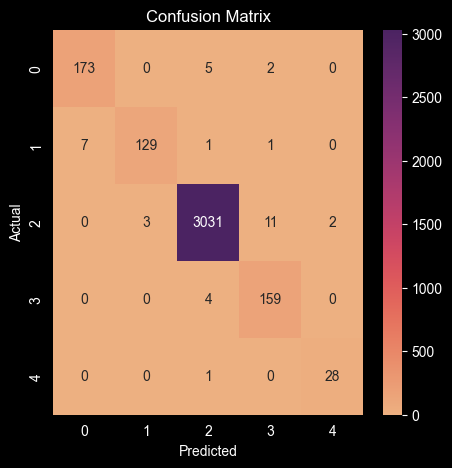

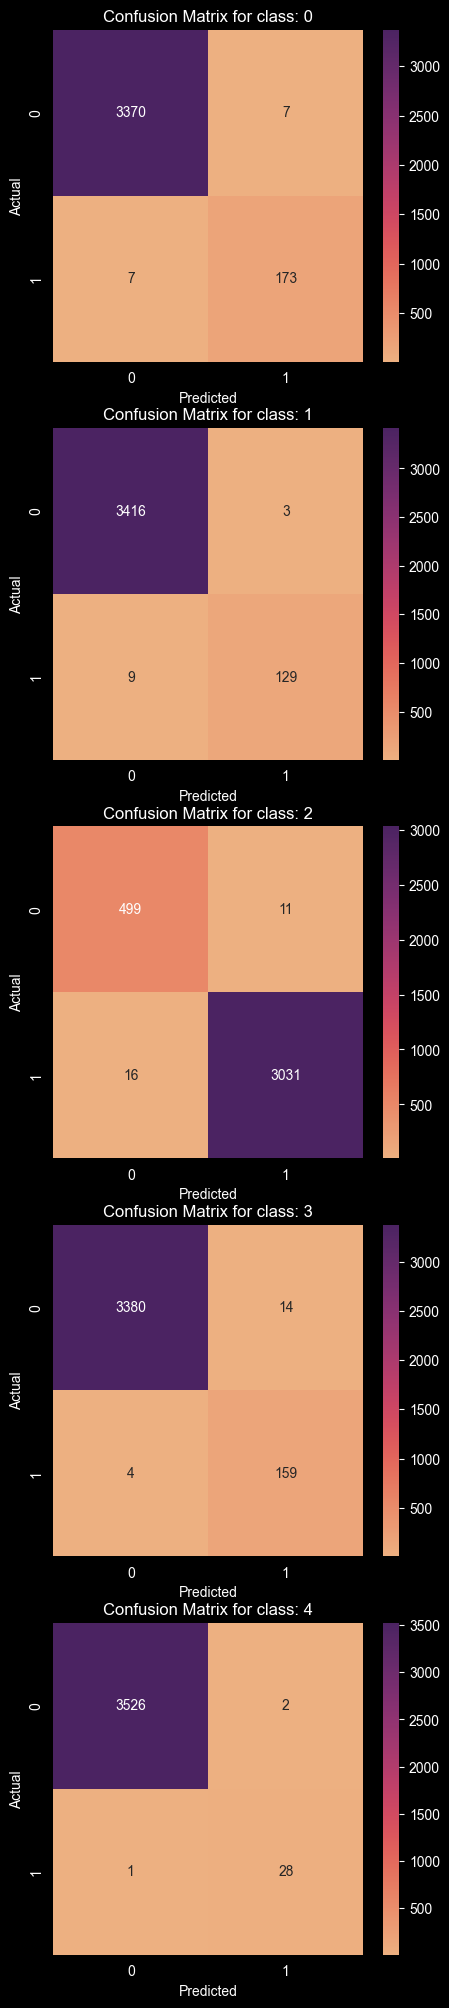

In [127]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=axes,  cmap='flare')
axes.set_title(f"Confusion Matrix")
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')
cm = multilabel_confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
for i, (m) in enumerate(cm):
    sns.heatmap(m, annot=True, fmt='d', ax=axes[i],  cmap='flare')
    axes[i].set_title(f"Confusion Matrix for class: {i}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
cm = multilabel_confusion_matrix(y_test, y_pred)

In [128]:

acc = []
for m in cm:
	#print(m[0][0]+m[1][1])
	acc.append(float((m[0][0]+m[1][1])/sum(sum(m))))
print('Точність по класам:')
acc

Точність по класам:


[0.9960640989597975,
 0.9966263705369693,
 0.9924093337081811,
 0.994939555805454,
 0.9991565926342424]

Бачимо 16 та 11 FP FN. Можна покращити результат

## Random Forest з oversampling

Повторимо тренування класифікатора використовуючи oversampling метод побудови датасету. Обрано саме oversampling через замалий розмір датасету (альтернатива - undersampling кожного класу до 34 екземплярів що негативно вплине на якість класифікатора)

In [129]:
max_class_count = train_df['final_label'].value_counts().max()
print(f'Максимальний клас має {max_class_count} зразків')
print(f'Розподіл до oversampling:)', '\n',
	  f'{train_df["final_label"].value_counts()}')

train_oversampled = pd.concat([
    group.sample(n=max_class_count, replace=True, random_state=42)
    for _, group in train_df.groupby('final_label')
]).reset_index(drop=True)

print(f'Розподіл після oversampling:',
	  f'{train_oversampled["final_label"].value_counts()}')

Максимальний клас має 3027 зразків
Розподіл до oversampling:) 
 final_label
2    3027
0     175
3     170
1     151
4      34
Name: count, dtype: int64
Розподіл після oversampling: final_label
0    3027
1    3027
2    3027
3    3027
4    3027
Name: count, dtype: int64


In [130]:
X_train = train_oversampled.drop(columns=['final_label']).values
y_train = train_oversampled['final_label'].values

rf = RandomForestClassifier(n_estimators=1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.9930
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       180
           1       0.96      0.99      0.98       138
           2       1.00      1.00      1.00      3047
           3       0.96      0.98      0.97       163
           4       1.00      0.97      0.98        29

    accuracy                           0.99      3557
   macro avg       0.98      0.98      0.98      3557
weighted avg       0.99      0.99      0.99      3557



Отримали покращення моделі до точності 99.3% Побудуємо матриці невідповідності

Точність по класам:


[0.9971886421141412,
 0.9980320494798988,
 0.9938150126511105,
 0.9971886421141412,
 0.9997188642114141]

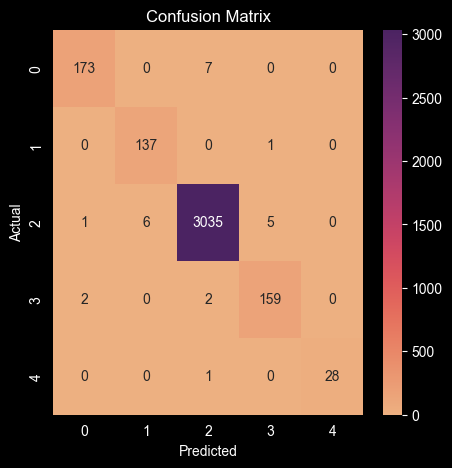

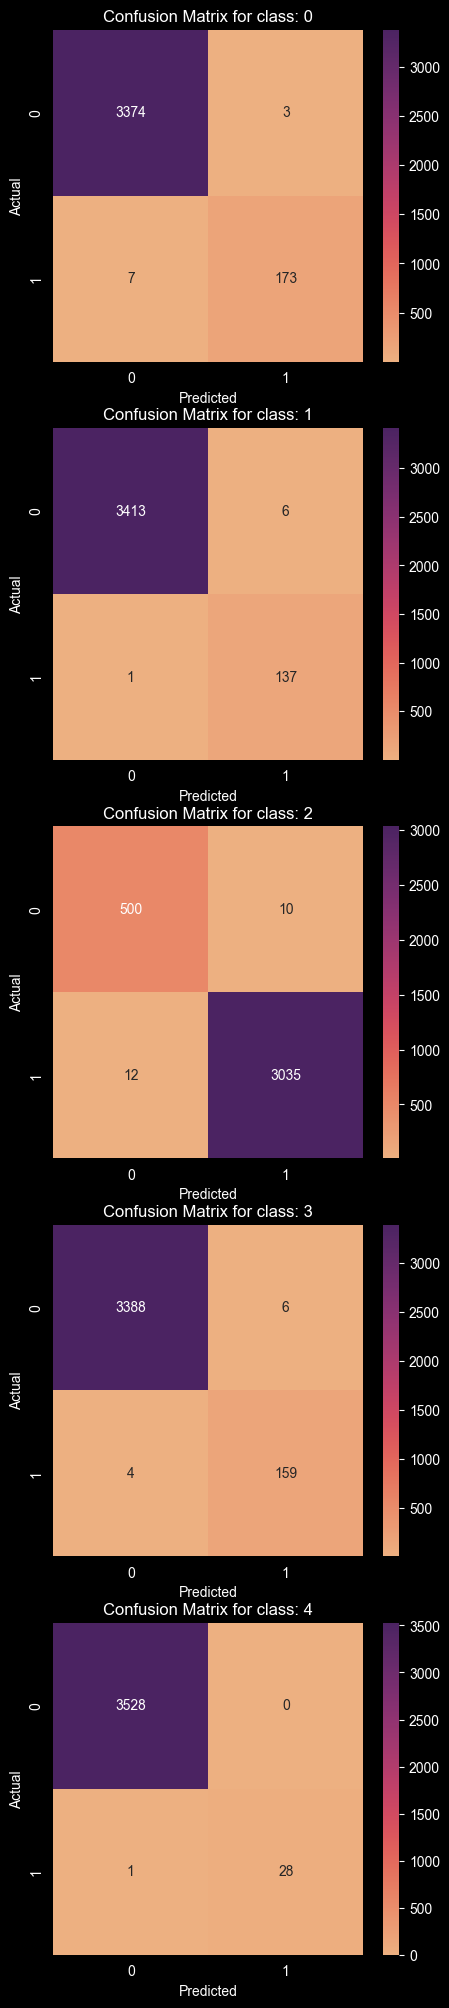

In [131]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=axes,  cmap='flare')
axes.set_title(f"Confusion Matrix")
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')
cm = multilabel_confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
for i, (m) in enumerate(cm):
    sns.heatmap(m, annot=True, fmt='d', ax=axes[i],  cmap='flare')
    axes[i].set_title(f"Confusion Matrix for class: {i}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
cm = multilabel_confusion_matrix(y_test, y_pred)

acc = []
for m in cm:
	#print(m[0][0]+m[1][1])
	acc.append(float((m[0][0]+m[1][1])/sum(sum(m))))
print('Точність по класам:')
acc

Кількість False Positive/False Negative (головна проблема в незбалансованих датасетах) для домінуючого класу впала. Метод спрацював


# Висновок

Дисбаланс даних погано впливає на результат моделькі. Oversampling та Undersampling є дієвими методами для покращення класифікації underrepresented класів

Датасет отримано з https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data
